In [1]:
import numpy as np
from IQAEBinom import IQAEBinom
import matplotlib.pyplot as plt
import pickle
from BiasCorrection import BiasExact
import datetime

In [2]:
epsilon = 0.001
nEstim = 10000
alpha = 0.05
nShotUnit = 1

In [3]:
#ps = np.linspace(0.001, 0.999, 201)
ps = np.linspace(0.001, 0.999, 5)

In [4]:
errAvgs = np.array([])
errStds = np.array([])
biasesMonte = np.array([])
for p in ps:
    print(p, datetime.datetime.now())
    results = np.array([])

    for i in range(nEstim):
        result = IQAEBinom(p, epsilon, alpha, nShotUnit, confint_method="chernoff")
        results = np.append(results, result)

    resFileName = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/results_IQAE_pTrue" + str(p) + "_epsilon0001_alpha005.dat"
    with open(resFileName, 'wb') as f:
        pickle.dump(results, f) 
    biases = [BiasExact(p, r["nGrover"][-1], r["nShots"][-1]) for r in results]    
    biasesMonte = np.append(biasesMonte, np.mean(biases))
    errs = [r["Estimate"] - p for r in results]
    errAvgs = np.append(errAvgs, np.mean(errs))
    errStds = np.append(errStds, np.std(errs))


0.001 2023-08-30 14:57:25.058634
0.2505 2023-08-30 14:58:23.585357
0.5 2023-08-30 15:03:21.176992
0.7494999999999999 2023-08-30 15:05:28.951726
0.999 2023-08-30 15:10:20.691700


In [5]:
biasesMonte

array([-7.14551548e-06, -1.02774042e-07,  8.28153995e-17,  3.89333305e-08,
        7.45349214e-06])

In [6]:
errAvgs

array([-6.99660242e-05,  3.36671098e-05,  2.29715675e-06, -3.85527193e-05,
        6.76697580e-05])

In [15]:
errStds

array([0.00022596, 0.00028263, 0.00033512, 0.00028457, 0.00023099])

In [10]:
with open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/results_IQAE_pTrue0.001_epsilon0001_alpha005.dat", 'rb') as f:
    results = pickle.load(f)
errs = [r["Estimate"] - ps[0] for r in results]
print(np.mean(errs), np.std(errs))

-6.996602420472433e-05 0.00022595590827951598


3.36671098407153e-05 0.00028262657864591397


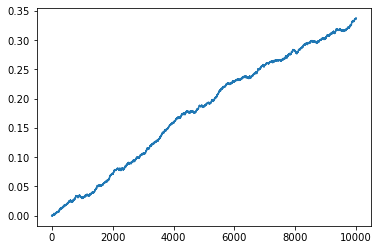

In [17]:
with open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/results_IQAE_pTrue0.2505_epsilon0001_alpha005.dat", 'rb') as f:
    results = pickle.load(f)
errs = [r["Estimate"] - ps[1] for r in results]
print(np.mean(errs), np.std(errs))

ax = plt.gca()
plt.plot(np.array(errs).cumsum())
plt.show()

In [18]:
results[0]

{'Estimate': 0.2502696737391592,
 'TotalOracleCalls': 28021,
 'nGrover': [0, 2, 5, 12, 27, 56, 114, 240],
 'nShots': [439, 125, 167, 60, 57, 54, 25, 18],
 'n1s': [103, 34, 28, 20, 14, 14, 10, 7],
 'thetaIntervals': [[0, 1.5707963267948966],
  [0.3597290379862299, 0.6281484644639662],
  [0.4785809450952467, 0.5707180582362611],
  [0.5159649280443717, 0.5623561688671262],
  [0.5143182664320889, 0.5374478440329231],
  [0.5149365949947922, 0.5281588188562067],
  [0.5213208018490032, 0.5268878458012858],
  [0.5225120490578012, 0.5257679887385529],
  [0.5228842756175762, 0.5246771712887257]],
 'ampSqIntervals': [[0, 1],
  [0.12391852243761696, 0.345329769134137],
  [0.21207868561751061, 0.2918554148770527],
  [0.24341828817915692, 0.28428197635216096],
  [0.24200636746495013, 0.26208800379836983],
  [0.24253622253796583, 0.2539594554838971],
  [0.24802981826639278, 0.25285380677979635],
  [0.24905945843698582, 0.2518809405316918],
  [0.24938148033135246, 0.2509344988075899]]}

In [19]:
ps[1]

0.2505

2.2971567462364673e-06 0.00033511855918054223


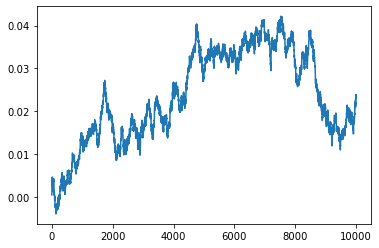

In [20]:
with open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/results_IQAE_pTrue0.5_epsilon0001_alpha005.dat", 'rb') as f:
    results = pickle.load(f)
errs = [r["Estimate"] - ps[2] for r in results]
print(np.mean(errs), np.std(errs))

ax = plt.gca()
plt.plot(np.array(errs).cumsum())
plt.show()

-3.8552719270659607e-05 0.0002845701955790315


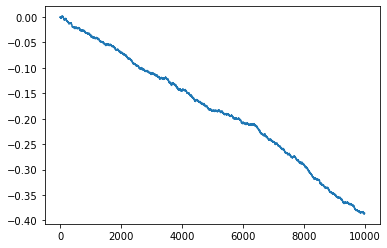

In [21]:
with open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/results_IQAE_pTrue0.7494999999999999_epsilon0001_alpha005.dat", 'rb') as f:
    results = pickle.load(f)
errs = [r["Estimate"] - ps[3] for r in results]
print(np.mean(errs), np.std(errs))

ax = plt.gca()
plt.plot(np.array(errs).cumsum())
plt.show()

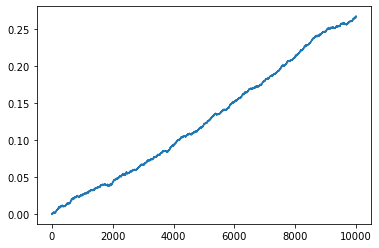

In [22]:
p = 0.2505
alpha = 0.05 / nEstim
errAvgs = np.array([])
errStds = np.array([])
results = np.array([])

for i in range(nEstim):
    result = IQAEBinom(p, epsilon, alpha, nShotUnit, confint_method="chernoff")
    results = np.append(results, result)

errs = [r["Estimate"] - p for r in results]
errAvgs = np.append(errAvgs, np.mean(errs))
errStds = np.append(errStds, np.std(errs))

ax = plt.gca()
plt.plot(np.array(errs).cumsum())
plt.show()

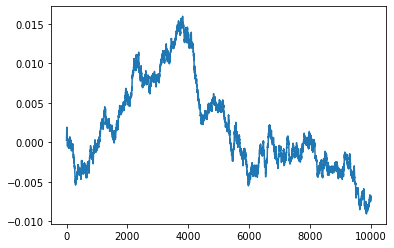

In [25]:
p = 0.1
alpha = 0.05 / nEstim
errAvgs = np.array([])
errStds = np.array([])
results = np.array([])

for i in range(nEstim):
    result = IQAEBinom(p, epsilon, alpha, nShotUnit, confint_method="chernoff")
    results = np.append(results, result)

errs = [r["Estimate"] - p for r in results]
errAvgs = np.append(errAvgs, np.mean(errs))
errStds = np.append(errStds, np.std(errs))

ax = plt.gca()
plt.plot(np.array(errs).cumsum())
plt.show()

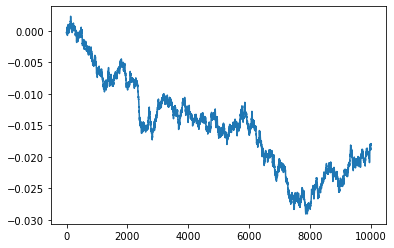

In [27]:
p = 0.2
alpha = 0.05 / nEstim
errAvgs = np.array([])
errStds = np.array([])
results = np.array([])

for i in range(nEstim):
    result = IQAEBinom(p, epsilon, alpha, nShotUnit, confint_method="chernoff")
    results = np.append(results, result)

errs = [r["Estimate"] - p for r in results]
errAvgs = np.append(errAvgs, np.mean(errs))
errStds = np.append(errStds, np.std(errs))

ax = plt.gca()
plt.plot(np.array(errs).cumsum())
plt.show()